Building a Convolutional Neural Network (CNN)

WorkFlow :
Input Layer -> [Convolutional layer -> Activation Layer -> Pooling Layer] -> Output layer

In [13]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import pandas as pd
from torchvision.transforms import ToTensor

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
train_data = datasets.FashionMNIST(
    train = True,
    root = 'data',
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    train = False,
    root = 'data',
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.0MB/s]


In [6]:
class_names = train_data.classes

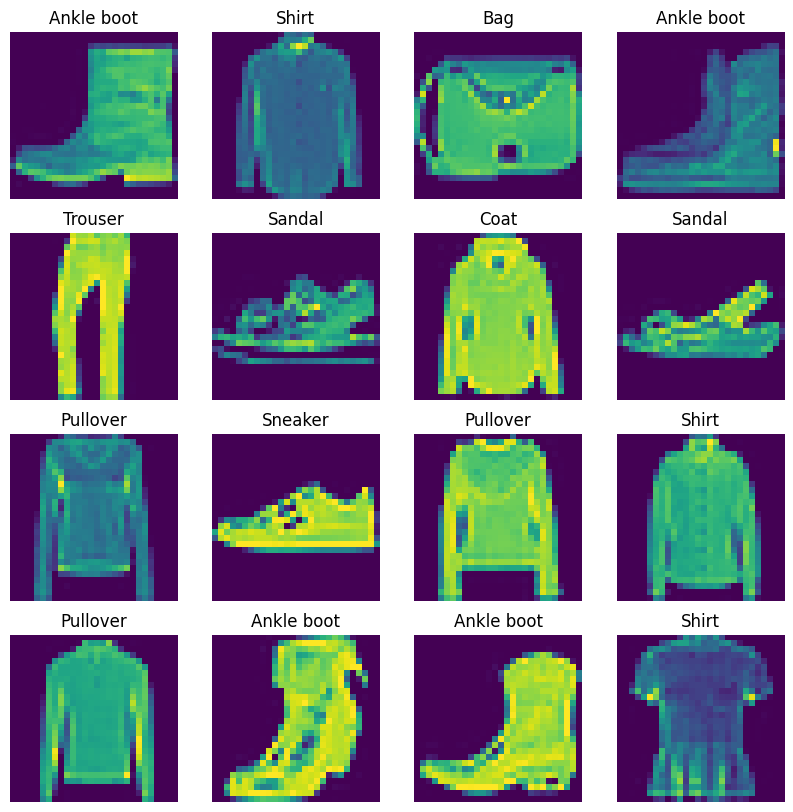

In [7]:
row , col = 4 , 4
plt.figure(figsize = (10 , 10))
for i in range(1 , row * col  + 1):
  random_inx = torch.randint(0 , len(train_data) , size = [1]).item()
  image,label = train_data[random_inx]
  plt.subplot(row , col , i)
  plt.imshow(image.squeeze())
  plt.title(class_names[label])
  plt.axis('off')

In [8]:
train_dataloader = DataLoader(batch_size = 32 , shuffle = True , dataset  = train_data)
test_dataloader = DataLoader(batch_size = 32 , shuffle = False , dataset = test_data)

In [9]:
class FirstCNNModel(nn.Module):
  def __init__(self , input_shape : int , hidden_shape : int , output_shape : int):
    super().__init__()
    self.block_1 = nn.Sequential(

      nn.Conv2d(in_channels=input_shape , out_channels=hidden_shape , kernel_size = 3 , stride = 1 , padding = 1),
      nn.ReLU(),
      nn.Conv2d(in_channels=hidden_shape , out_channels=hidden_shape , kernel_size = 3 , stride = 1 , padding = 1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2 , stride = 2)
    )

    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_shape, hidden_shape, 3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_shape, hidden_shape, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_shape * 7 * 7 , out_features=output_shape)
    )
  def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        #print(x.shape)
        x = self.block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)
        return x

torch.manual_seed(42)
model_1 = FirstCNNModel(input_shape=1,
    hidden_shape=10,
    output_shape=len(class_names)).to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [10]:
loss_fn  = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_1.parameters() , lr = 0.1)

In [11]:
def train_loop(model, data_loader, loss_fn, optimizer,device: torch.device = device):
    model.to(device)
    model.train()
    total_loss = 0
    for batch , (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 500 == 0:
          print(f"Batch : {batch}")
    return total_loss / len(data_loader)

def test_loop(model, data_loader, loss_fn,device: torch.device = device):
    model.to(device)
    model.eval()
    test_loss = 0
    with torch.inference_mode():
        for batch , (X, y) in enumerate(data_loader):
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y).item()
            if batch % 500 == 0:
              print(f"Batch : {batch}")
    return test_loss / len(data_loader)

In [15]:
def TimeTake(starttime , endtime):
  print(f"Total Time Taken Is : {endtime - starttime}")

In [16]:
epochs = 3
start_time = timer()
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_loss = train_loop(model = model_1 , data_loader=train_dataloader , loss_fn=loss_fn , optimizer=optimizer)
  test_loss = test_loop(model  = model_1  , data_loader=
  test_dataloader , loss_fn=loss_fn  )
  print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
endtime = timer()
TimeTake(start_time , endtime)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Batch : 0
Batch : 500
Batch : 1000
Batch : 1500
Batch : 0
Epoch: 0 | Train Loss: 0.2823 | Test Loss: 0.3353
Epoch: 1
---------
Batch : 0
Batch : 500
Batch : 1000
Batch : 1500
Batch : 0
Epoch: 1 | Train Loss: 0.2715 | Test Loss: 0.2931
Epoch: 2
---------
Batch : 0
Batch : 500
Batch : 1000
Batch : 1500
Batch : 0
Epoch: 2 | Train Loss: 0.2614 | Test Loss: 0.2955
Total Time Taken Is : 35.27364701300007
